In [ ]:
# DAY 17 - FIX CELL 1
# Recreate required libraries, dataset path, device and U-Net

import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from google.colab import drive

drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Underwater-Image-Data-set-main"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dataset path:", BASE_PATH)
print("Path exists:", os.path.exists(BASE_PATH))
print("Device:", device)


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.middle = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv1 = DoubleConv(64, 32)

        self.final = nn.Conv2d(32, 3, 1)

    def forward(self, x):

        x1 = self.down1(x)
        x2 = self.down2(self.pool1(x1))
        x3 = self.down3(self.pool2(x2))

        middle = self.middle(self.pool3(x3))

        y3 = self.up3(middle)
        y3 = torch.cat([y3, x3], dim=1)
        y3 = self.conv3(y3)

        y2 = self.up2(y3)
        y2 = torch.cat([y2, x2], dim=1)
        y2 = self.conv2(y2)

        y1 = self.up1(y2)
        y1 = torch.cat([y1, x1], dim=1)
        y1 = self.conv1(y1)

        output = self.final(y1)

        return torch.sigmoid(output)


print("U-Net is ready.")

Mounted at /content/drive
Dataset path: /content/drive/MyDrive/Underwater-Image-Data-set-main
Path exists: True
Device: cuda
U-Net is ready.


In [ ]:
# DAY 17 - CELL 2
# Recreate frozen Dataset V1 split and DataLoaders

# Collect Input-Target pairs

pairs = []

for root, dirs, files in os.walk(BASE_PATH):
    for file in files:

        if "_input" in file.lower() and file.lower().endswith((".png", ".jpg", ".jpeg")):

            input_path = os.path.join(root, file)
            sample_id = file.rsplit("_input", 1)[0]

            target_path = os.path.join(
                root,
                sample_id + "_target.png"
            )

            if os.path.exists(target_path):
                pairs.append((input_path, target_path))

pairs = sorted(pairs)

print("Total Input-Target pairs:", len(pairs))


# Create the frozen split

split_path = os.path.join(
    BASE_PATH,
    "Dataset_V1_frozen_split.json"
)

if os.path.exists(split_path):

    with open(split_path, "r") as f:
        saved_split = json.load(f)

    train_pairs = [tuple(x) for x in saved_split["train"]]
    val_pairs = [tuple(x) for x in saved_split["validation"]]
    test_pairs = [tuple(x) for x in saved_split["test"]]

    print("Frozen Dataset V1 split loaded.")

else:

    random.seed(42)

    shuffled_pairs = pairs.copy()
    random.shuffle(shuffled_pairs)

    total = len(shuffled_pairs)

    train_end = int(0.70 * total)
    val_end = train_end + int(0.15 * total)

    train_pairs = shuffled_pairs[:train_end]
    val_pairs = shuffled_pairs[train_end:val_end]
    test_pairs = shuffled_pairs[val_end:]

    saved_split = {
        "train": train_pairs,
        "validation": val_pairs,
        "test": test_pairs
    }

    with open(split_path, "w") as f:
        json.dump(saved_split, f, indent=4)

    print("New frozen Dataset V1 split created.")


# Create Dataset class

class UnderwaterDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):

        input_path, target_path = self.pairs[index]

        input_image = Image.open(input_path).convert("RGB")
        target_image = Image.open(target_path).convert("RGB")

        input_image = input_image.resize((256, 256))
        target_image = target_image.resize((256, 256))

        input_array = np.array(
            input_image,
            dtype=np.float32
        ) / 255.0

        target_array = np.array(
            target_image,
            dtype=np.float32
        ) / 255.0

        input_tensor = torch.from_numpy(
            input_array
        ).permute(2, 0, 1)

        target_tensor = torch.from_numpy(
            target_array
        ).permute(2, 0, 1)

        return input_tensor, target_tensor


# Create datasets

train_dataset = UnderwaterDataset(train_pairs)
val_dataset = UnderwaterDataset(val_pairs)
test_dataset = UnderwaterDataset(test_pairs)


# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)


print("\nTraining pairs   :", len(train_pairs))
print("Validation pairs :", len(val_pairs))
print("Testing pairs    :", len(test_pairs))

print("\nTraining batches   :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches   :", len(test_loader))

Total Input-Target pairs: 1233
Frozen Dataset V1 split loaded.

Training pairs   : 863
Validation pairs : 184
Testing pairs    : 186

Training batches   : 108
Validation batches: 23
Testing batches   : 24


In [ ]:
# DAY 17 - CELL 3
# Experiment A

print("========== EXPERIMENT A ==========")
print("Learning rate: 0.001")

model_A = UNet().to(device)

criterion_A = nn.L1Loss()

optimizer_A = optim.Adam(
    model_A.parameters(),
    lr=0.001
)

epochs = 5

train_A = []
val_A = []

best_A = float("inf")
best_state_A = None

for epoch in range(epochs):

    model_A.train()

    total_train_loss = 0.0

    for inputs, targets in train_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer_A.zero_grad()

        outputs = model_A(inputs)

        loss = criterion_A(outputs, targets)

        loss.backward()

        optimizer_A.step()

        total_train_loss += loss.item()

    train_loss = total_train_loss / len(train_loader)

    model_A.eval()

    total_val_loss = 0.0

    with torch.no_grad():

        for inputs, targets in val_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model_A(inputs)

            loss = criterion_A(outputs, targets)

            total_val_loss += loss.item()

    val_loss = total_val_loss / len(val_loader)

    train_A.append(train_loss)
    val_A.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_A:

        best_A = val_loss
        best_state_A = model_A.state_dict()

print("\nExperiment A completed.")
print("Best validation loss:", round(best_A, 4))

========== EXPERIMENT A ==========
Learning rate: 0.001
Epoch 1/5 | Train Loss: 0.1892 | Val Loss: 0.1927
Epoch 2/5 | Train Loss: 0.1832 | Val Loss: 0.1863
Epoch 3/5 | Train Loss: 0.1832 | Val Loss: 0.1841
Epoch 4/5 | Train Loss: 0.1803 | Val Loss: 0.1843
Epoch 5/5 | Train Loss: 0.1801 | Val Loss: 0.1875

Experiment A completed.
Best validation loss: 0.1841


In [ ]:
# DAY 17 - CELL 4
print("========== EXPERIMENT B ==========")
print("Learning rate: 0.0001")

model_B = UNet().to(device)

criterion_B = nn.L1Loss()
optimizer_B = optim.Adam(model_B.parameters(), lr=0.0001)

train_B = []
val_B = []

best_B = float("inf")
best_state_B = None

for epoch in range(epochs):

    model_B.train()
    total_train_loss = 0.0

    for inputs, targets in train_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer_B.zero_grad()

        outputs = model_B(inputs)

        loss = criterion_B(outputs, targets)

        loss.backward()
        optimizer_B.step()

        total_train_loss += loss.item()

    train_loss = total_train_loss / len(train_loader)

    model_B.eval()
    total_val_loss = 0.0

    with torch.no_grad():

        for inputs, targets in val_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model_B(inputs)

            loss = criterion_B(outputs, targets)

            total_val_loss += loss.item()

    val_loss = total_val_loss / len(val_loader)

    train_B.append(train_loss)
    val_B.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_B:
        best_B = val_loss
        best_state_B = model_B.state_dict()

print("\nExperiment B completed.")
print("Best validation loss:", round(best_B, 4))

========== EXPERIMENT B ==========
Learning rate: 0.0001
Epoch 1/5 | Train Loss: 0.2010 | Val Loss: 0.2025
Epoch 2/5 | Train Loss: 0.1871 | Val Loss: 0.1977
Epoch 3/5 | Train Loss: 0.1783 | Val Loss: 0.1808
Epoch 4/5 | Train Loss: 0.1750 | Val Loss: 0.1768
Epoch 5/5 | Train Loss: 0.1733 | Val Loss: 0.1759

Experiment B completed.
Best validation loss: 0.1759


In [ ]:
print("========== DAY 17 COMPARISON ==========")

print("Experiment A - LR 0.001")
print("Best Validation Loss:", round(best_A, 4))

print()

print("Experiment B - LR 0.0001")
print("Best Validation Loss:", round(best_B, 4))


if best_A < best_B:

    print("\nSelected Experiment A")
    print("Learning rate = 0.001")

    best_model = UNet().to(device)
    best_model.load_state_dict(best_state_A)

    selected_lr = 0.001

else:

    print("\nSelected Experiment B")
    print("Learning rate = 0.0001")

    best_model = UNet().to(device)
    best_model.load_state_dict(best_state_B)

    selected_lr = 0.0001


print("\nSelected learning rate:", selected_lr)

========== DAY 17 COMPARISON ==========
Experiment A - LR 0.001
Best Validation Loss: 0.1841

Experiment B - LR 0.0001
Best Validation Loss: 0.1759

Selected Experiment B
Learning rate = 0.0001

Selected learning rate: 0.0001


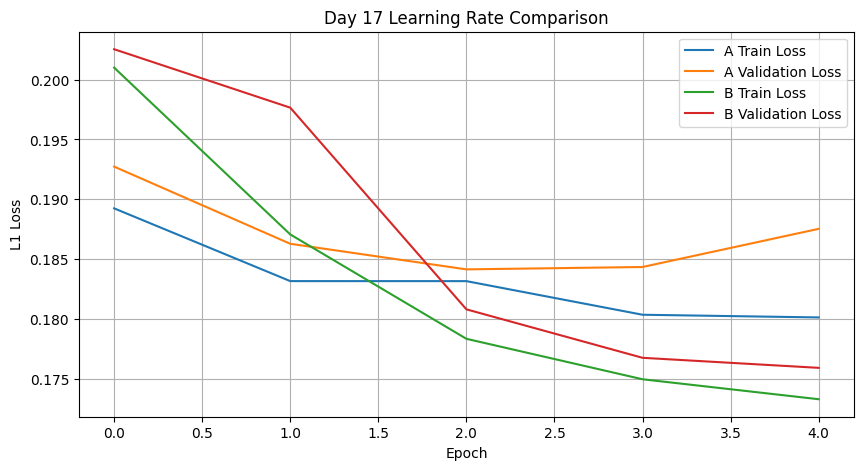

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(train_A, label="A Train Loss")
plt.plot(val_A, label="A Validation Loss")

plt.plot(train_B, label="B Train Loss")
plt.plot(val_B, label="B Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Day 17 Learning Rate Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
if best_A < best_B:
    selected_lr = 0.001
    selected_loss = best_A
    selected_state = best_state_A
    selected_experiment = "Experiment A"
else:
    selected_lr = 0.0001
    selected_loss = best_B
    selected_state = best_state_B
    selected_experiment = "Experiment B"

best_model = UNet().to(device)
best_model.load_state_dict(selected_state)
best_model.eval()

print("Selected:", selected_experiment)
print("Learning rate:", selected_lr)
print("Best validation loss:", round(selected_loss, 4))

Selected: Experiment B
Learning rate: 0.0001
Best validation loss: 0.1759


In [ ]:
save_folder = os.path.join(
    BASE_PATH,
    "Day17_Results"
)

os.makedirs(save_folder, exist_ok=True)

model_path = os.path.join(
    save_folder,
    "best_unet_model.pth"
)

torch.save(
    best_model.state_dict(),
    model_path
)

print("Best model saved:")
print(model_path)

Best model saved:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Day17_Results/best_unet_model.pth


In [ ]:
inputs, targets = next(iter(val_loader))

inputs = inputs.to(device)
targets = targets.to(device)

with torch.no_grad():
    outputs = best_model(inputs)

inputs = inputs.cpu()
outputs = outputs.cpu()
targets = targets.cpu()

print("Input:", inputs.shape)
print("Output:", outputs.shape)
print("Target:", targets.shape)

Input: torch.Size([8, 3, 256, 256])
Output: torch.Size([8, 3, 256, 256])
Target: torch.Size([8, 3, 256, 256])


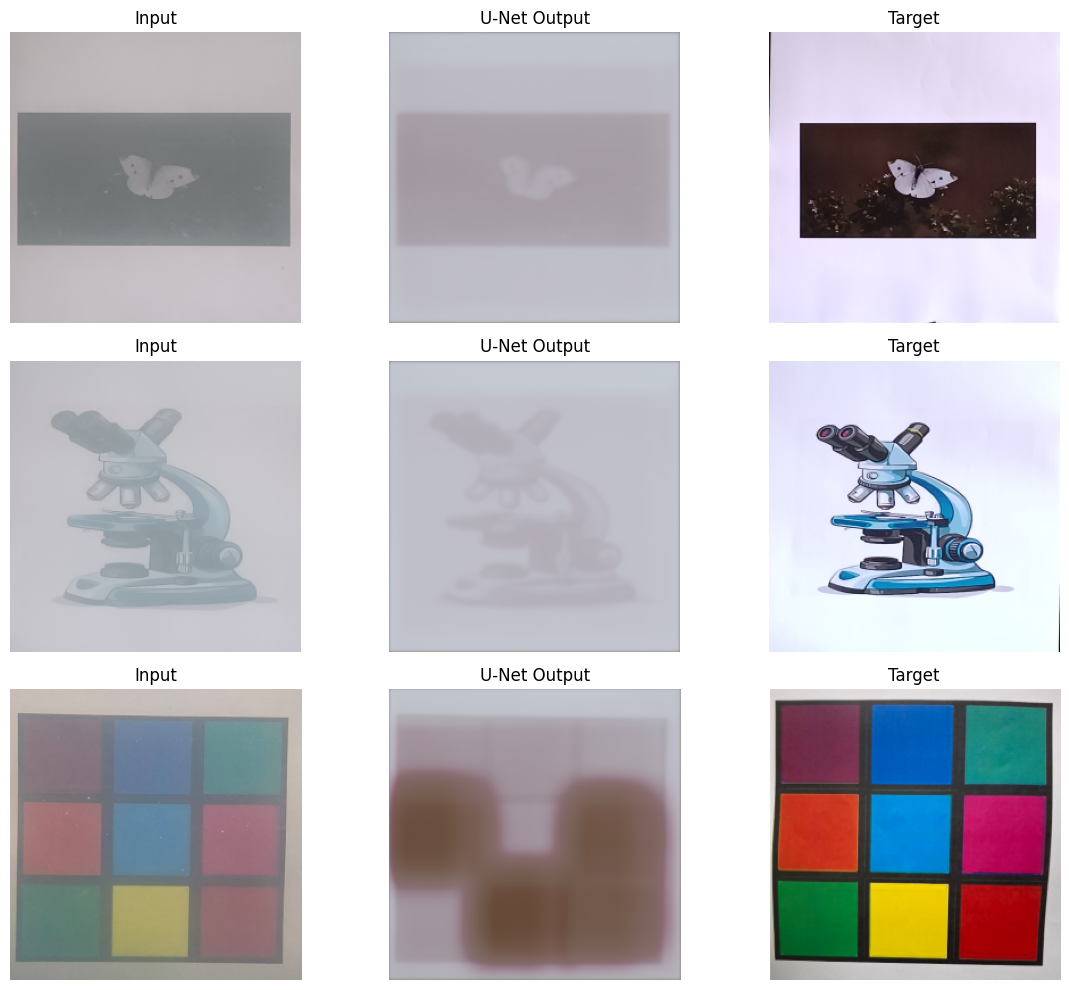

In [ ]:
plt.figure(figsize=(12, 10))

for i in range(3):

    plt.subplot(3, 3, i * 3 + 1)
    plt.imshow(inputs[i].permute(1, 2, 0).numpy())
    plt.title("Input")
    plt.axis("off")

    plt.subplot(3, 3, i * 3 + 2)
    plt.imshow(outputs[i].permute(1, 2, 0).numpy())
    plt.title("U-Net Output")
    plt.axis("off")

    plt.subplot(3, 3, i * 3 + 3)
    plt.imshow(targets[i].permute(1, 2, 0).numpy())
    plt.title("Target")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
day19_log = {
    "model": "U-Net",
    "dataset": "Dataset V1",
    "loss_function": "L1Loss",
    "optimizer": "Adam",
    "epochs": 5,
    "Experiment_A": {
        "learning_rate": 0.001,
        "best_validation_loss": float(best_A)
    },
    "Experiment_B": {
        "learning_rate": 0.0001,
        "best_validation_loss": float(best_B)
    }
}

print("========== DAY 19 EXPERIMENT LOG ==========")

print("Experiment A")
print("Learning rate:", 0.001)
print("Best validation loss:", round(best_A, 4))

print()

print("Experiment B")
print("Learning rate:", 0.0001)
print("Best validation loss:", round(best_B, 4))

========== DAY 19 EXPERIMENT LOG ==========
Experiment A
Learning rate: 0.001
Best validation loss: 0.1841

Experiment B
Learning rate: 0.0001
Best validation loss: 0.1759


In [ ]:
if best_A < best_B:
    day19_lr = 0.001
    day19_loss = best_A
    day19_experiment = "Experiment A"
else:
    day19_lr = 0.0001
    day19_loss = best_B
    day19_experiment = "Experiment B"

print("========== DAY 19 SELECTED CONFIGURATION ==========")
print("Selected experiment:", day19_experiment)
print("Selected learning rate:", day19_lr)
print("Validation loss:", round(day19_loss, 4))

========== DAY 19 SELECTED CONFIGURATION ==========
Selected experiment: Experiment B
Selected learning rate: 0.0001
Validation loss: 0.1759


In [ ]:
day19_config = {
    "model": "U-Net",
    "dataset": "Dataset V1",
    "loss_function": "L1Loss",
    "optimizer": "Adam",
    "epochs": 5,
    "selected_learning_rate": day19_lr,
    "selected_validation_loss": float(day19_loss)
}

day19_config_path = os.path.join(
    BASE_PATH,
    "Day19_Configuration.json"
)

with open(day19_config_path, "w") as f:
    json.dump(day19_config, f, indent=4)

print("Day 19 configuration saved.")
print(day19_config_path)

Day 19 configuration saved.
/content/drive/MyDrive/Underwater-Image-Data-set-main/Day19_Configuration.json


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def classical_enhancement(image):
    """
    Classical enhancement using CLAHE in LAB color space.
    Input: RGB image, values [0,1]
    Output: enhanced RGB image, values [0,1]
    """

    image_uint8 = (image * 255).astype(np.uint8)

    # Convert RGB -> LAB
    lab = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2LAB)

    # Split channels
    l, a, b = cv2.split(lab)

    # CLAHE on luminance channel
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l_enhanced = clahe.apply(l)

    # Merge channels
    enhanced_lab = cv2.merge([
        l_enhanced,
        a,
        b
    ])

    # LAB -> RGB
    enhanced_rgb = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2RGB
    )

    return enhanced_rgb.astype(np.float32) / 255.0

In [ ]:
best_model.eval()

inputs, targets = next(iter(val_loader))

inputs_gpu = inputs.to(device)

with torch.no_grad():
    unet_outputs = best_model(inputs_gpu)

inputs_np = inputs.numpy()
targets_np = targets.numpy()
unet_np = unet_outputs.cpu().numpy()

print("Validation batch:", inputs_np.shape)

Validation batch: (8, 3, 256, 256)


In [ ]:
classical_outputs = []

for i in range(len(inputs_np)):

    image = inputs_np[i].transpose(1, 2, 0)

    enhanced = classical_enhancement(image)

    classical_outputs.append(enhanced)

classical_outputs = np.array(classical_outputs)

print("Classical outputs:", classical_outputs.shape)

Classical outputs: (8, 256, 256, 3)


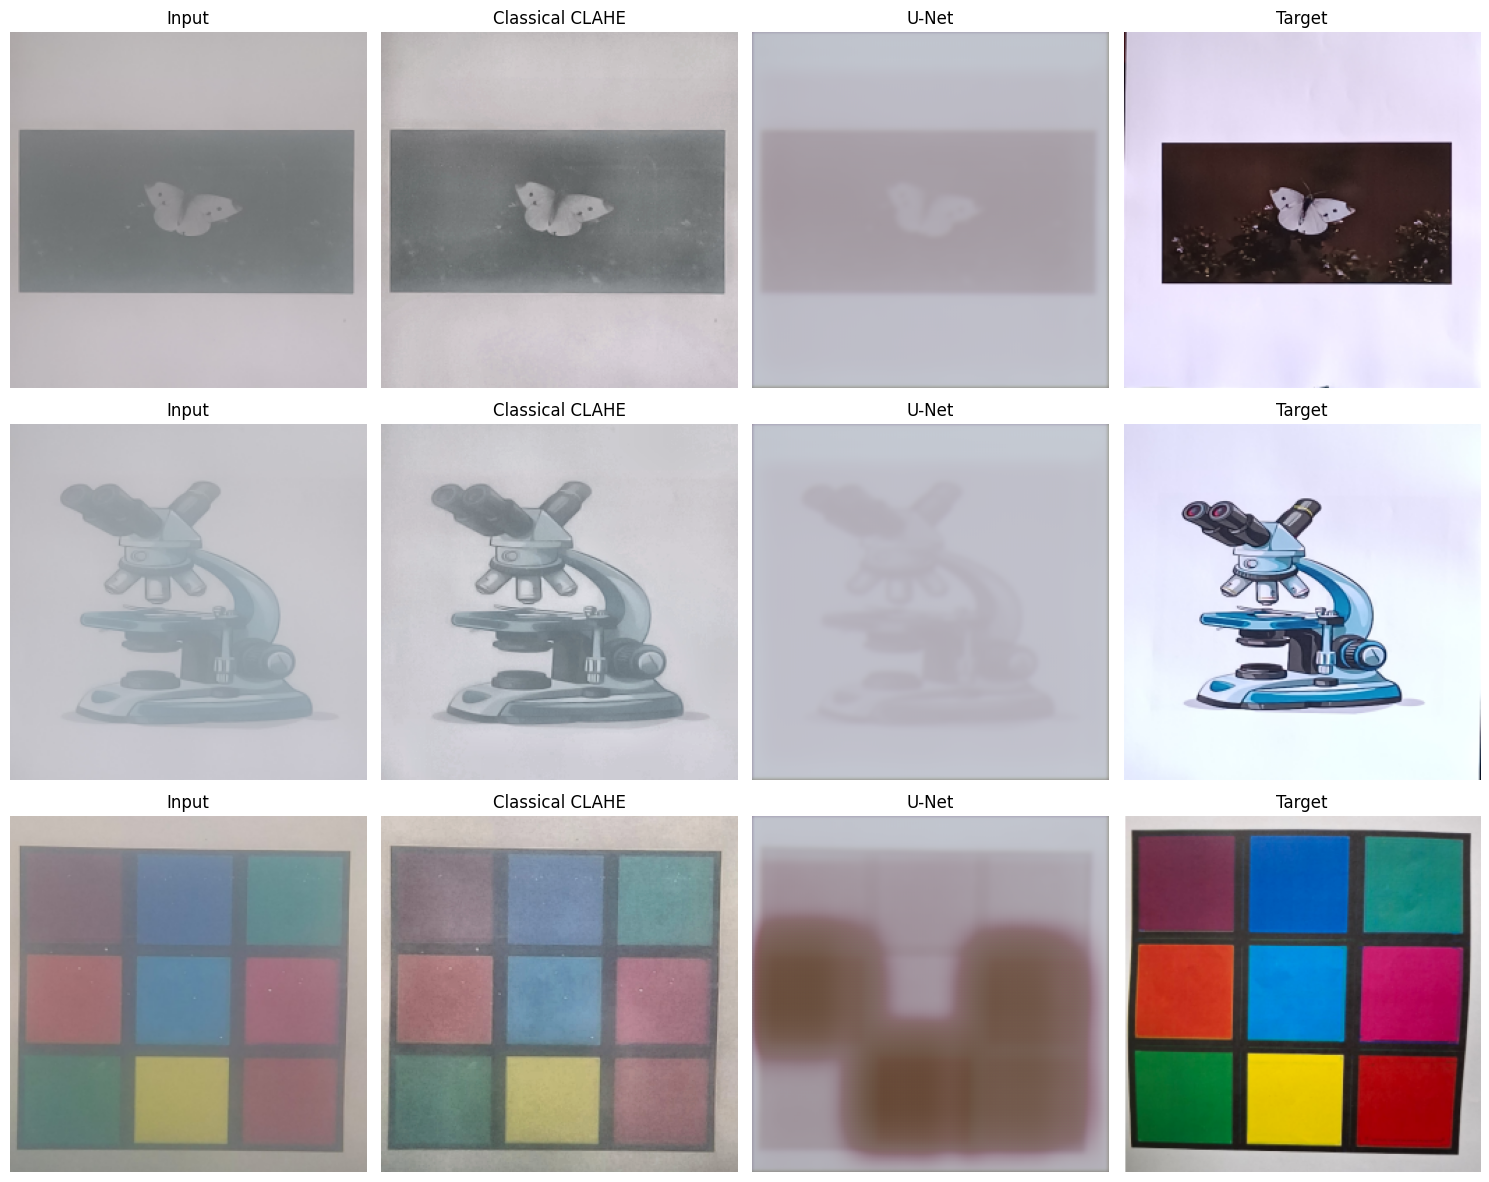

In [ ]:
num_images = 3

plt.figure(figsize=(15, 12))

for i in range(num_images):

    # Input
    plt.subplot(num_images, 4, i * 4 + 1)
    plt.imshow(inputs_np[i].transpose(1, 2, 0))
    plt.title("Input")
    plt.axis("off")

    # Classical
    plt.subplot(num_images, 4, i * 4 + 2)
    plt.imshow(classical_outputs[i])
    plt.title("Classical CLAHE")
    plt.axis("off")

    # U-Net
    plt.subplot(num_images, 4, i * 4 + 3)
    plt.imshow(unet_np[i].transpose(1, 2, 0))
    plt.title("U-Net")
    plt.axis("off")

    # Target
    plt.subplot(num_images, 4, i * 4 + 4)
    plt.imshow(targets_np[i].transpose(1, 2, 0))
    plt.title("Target")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def get_edges(image):

    image_uint8 = (image * 255).astype(np.uint8)

    gray = cv2.cvtColor(
        image_uint8,
        cv2.COLOR_RGB2GRAY
    )

    edges = cv2.Canny(
        gray,
        100,
        200
    )

    return edges

In [ ]:
def edge_preservation_score(output, target):

    output_edges = get_edges(output)
    target_edges = get_edges(target)

    output_edges = output_edges > 0
    target_edges = target_edges > 0

    intersection = np.logical_and(
        output_edges,
        target_edges
    ).sum()

    output_count = output_edges.sum()
    target_count = target_edges.sum()

    precision = intersection / (output_count + 1e-8)
    recall = intersection / (target_count + 1e-8)

    f1 = (
        2 * precision * recall /
        (precision + recall + 1e-8)
    )

    return f1

In [ ]:
unet_edge_scores = []
classical_edge_scores = []

for i in range(len(inputs_np)):

    target = targets_np[i].transpose(1, 2, 0)

    unet_output = unet_np[i].transpose(1, 2, 0)

    classical_output = classical_outputs[i]

    unet_score = edge_preservation_score(
        unet_output,
        target
    )

    classical_score = edge_preservation_score(
        classical_output,
        target
    )

    unet_edge_scores.append(unet_score)
    classical_edge_scores.append(classical_score)

print("Average U-Net Edge Score:",
      np.mean(unet_edge_scores))

print("Average Classical Edge Score:",
      np.mean(classical_edge_scores))

Average U-Net Edge Score: 0.0002879354655746334
Average Classical Edge Score: 0.08236249556182038


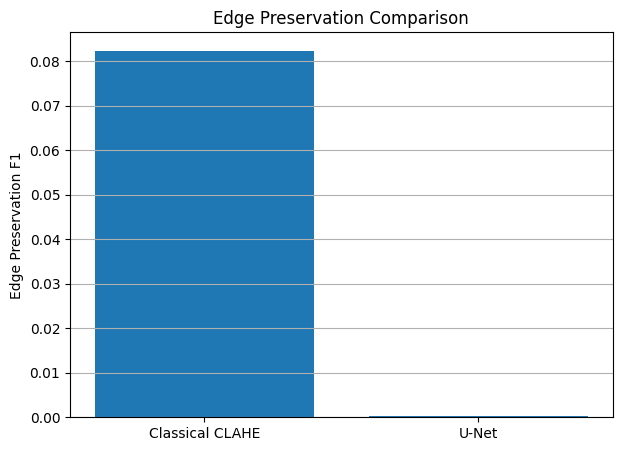

In [ ]:
methods = [
    "Classical CLAHE",
    "U-Net"
]

edge_scores = [
    np.mean(classical_edge_scores),
    np.mean(unet_edge_scores)
]

plt.figure(figsize=(7, 5))

plt.bar(
    methods,
    edge_scores
)

plt.ylabel("Edge Preservation F1")
plt.title("Edge Preservation Comparison")
plt.grid(axis="y")

plt.show()

In [ ]:
class UNet_NoSkip(nn.Module):

    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.middle = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(
            256, 128, 2, stride=2
        )

        self.conv3 = DoubleConv(
            128, 128
        )

        self.up2 = nn.ConvTranspose2d(
            128, 64, 2, stride=2
        )

        self.conv2 = DoubleConv(
            64, 64
        )

        self.up1 = nn.ConvTranspose2d(
            64, 32, 2, stride=2
        )

        self.conv1 = DoubleConv(
            32, 32
        )

        self.final = nn.Conv2d(
            32, 3, 1
        )

    def forward(self, x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        m = self.middle(p3)

        u3 = self.up3(m)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = self.conv1(u1)

        return torch.sigmoid(
            self.final(u1)
        )

In [ ]:
def train_ablation_model(epochs=5):

    model = UNet_NoSkip().to(device)

    criterion = nn.L1Loss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.0001
    )

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()

        total_train_loss = 0

        for inputs, targets in train_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(
                outputs,
                targets
            )

            loss.backward()

            optimizer.step()

            total_train_loss += loss.item()

        train_loss = (
            total_train_loss /
            len(train_loader)
        )

        model.eval()

        total_val_loss = 0

        with torch.no_grad():

            for inputs, targets in val_loader:

                inputs = inputs.to(device)
                targets = targets.to(device)

                outputs = model(inputs)

                loss = criterion(
                    outputs,
                    targets
                )

                total_val_loss += loss.item()

        val_loss = (
            total_val_loss /
            len(val_loader)
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train: {train_loss:.4f} | "
            f"Val: {val_loss:.4f}"
        )

    return model, train_losses, val_losses

In [ ]:
ablation_model, ablation_train, ablation_val = \
    train_ablation_model(epochs=5)

best_ablation_loss = min(ablation_val)

print()
print("========== ABLATION RESULT ==========")
print("Original U-Net best validation loss:",
      selected_loss)

print("No-Skip U-Net best validation loss:",
      best_ablation_loss)

Epoch 1/5 | Train: 0.2010 | Val: 0.2112
Epoch 2/5 | Train: 0.1983 | Val: 0.2075
Epoch 3/5 | Train: 0.1954 | Val: 0.2038
Epoch 4/5 | Train: 0.1939 | Val: 0.2019
Epoch 5/5 | Train: 0.1904 | Val: 0.1882

========== ABLATION RESULT ==========
Original U-Net best validation loss: 0.1759122337984002
No-Skip U-Net best validation loss: 0.1881973140913507


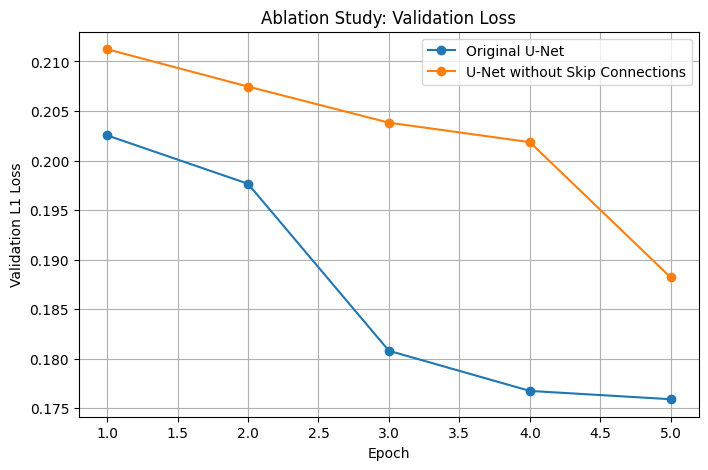

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    val_A if selected_lr == 0.001 else val_B,
    marker="o",
    label="Original U-Net"
)

plt.plot(
    range(1, 6),
    ablation_val,
    marker="o",
    label="U-Net without Skip Connections"
)

plt.xlabel("Epoch")
plt.ylabel("Validation L1 Loss")

plt.title(
    "Ablation Study: Validation Loss"
)

plt.legend()
plt.grid()

plt.show()

In [ ]:
day20_results = pd.DataFrame({
    "Method": [
        "Classical CLAHE",
        "Original U-Net",
        "U-Net without Skip Connections"
    ],

    "Edge Preservation F1": [
        np.mean(classical_edge_scores),
        np.mean(unet_edge_scores),
        np.nan
    ],

    "Best Validation L1 Loss": [
        np.nan,
        selected_loss,
        best_ablation_loss
    ]
})

day20_results

,Method,Edge Preservation F1,Best Validation L1 Loss
0,Classical CLAHE,0.082362,NaN
1,Original U-Net,0.000288,0.175912
2,U-Net without Skip Connections,NaN,0.188197


In [ ]:
day20_folder = os.path.join(
    BASE_PATH,
    "Day20_Results"
)

os.makedirs(
    day20_folder,
    exist_ok=True
)

day20_results_path = os.path.join(
    day20_folder,
    "day20_results.csv"
)

day20_results.to_csv(
    day20_results_path,
    index=False
)

print("Day 20 results saved:")
print(day20_results_path)

Day 20 results saved:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Day20_Results/day20_results.csv
